<a href="https://colab.research.google.com/github/djmdk-0412/EN3150_A03_GalTricals/blob/main/notebook/Assignment3_Main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EN3150 Assignment 03: Resource-Constrained CNN for Edge Image Classification
**Group Members**
- CHINTHAKA M.K.M.G. - 230105H
- DILMITH GS - 230149U
- KAUSHAL S.V. - 230326K
- RAJAPAKSHA J.S.W. - 230511A

## 1. Introduction & Data Preparation
For this assignment, we are building a lightweight image classifier designed for embedded or low resource devices. We final goal is deploying this model on an Automated Agricultural Sorting Machine (an edge device in a rice mill) that classifies rice grains in real time.

We selected the **Rice Image Dataset** from Kaggle (75,000 images across 5 classes).

**Hardware Context & Data Split Strategy:**
To strictly emulate a low-resource sensor environment, images are downscaled to 64x64 pixels. The dataset is split into:
- **Training Set - 70%**
- **Validation Set - 15%**
- **Testing Set - 15%**


In [2]:
# Setup Kaggle API and Download Rice Image Dataset
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Downloading Rice Image Dataset...")
!kaggle datasets download -d muratkokludataset/rice-image-dataset

print("Unzipping...")
!unzip -q rice-image-dataset.zip -d rice_dataset
print("Dataset Successfully Downloaded and Extracted!")


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/muratkokludataset/rice-image-dataset
License(s): CC0-1.0
100% 219M/219M [00:01<00:00, 148MB/s]

Unzipping...
Dataset Successfully Downloaded and Extracted!


Loading data from: rice_dataset/Rice_Image_Dataset
Found 75000 files belonging to 5 classes.
Using 52500 files for training.
Found 75000 files belonging to 5 classes.
Using 22500 files for validation.
Classes: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


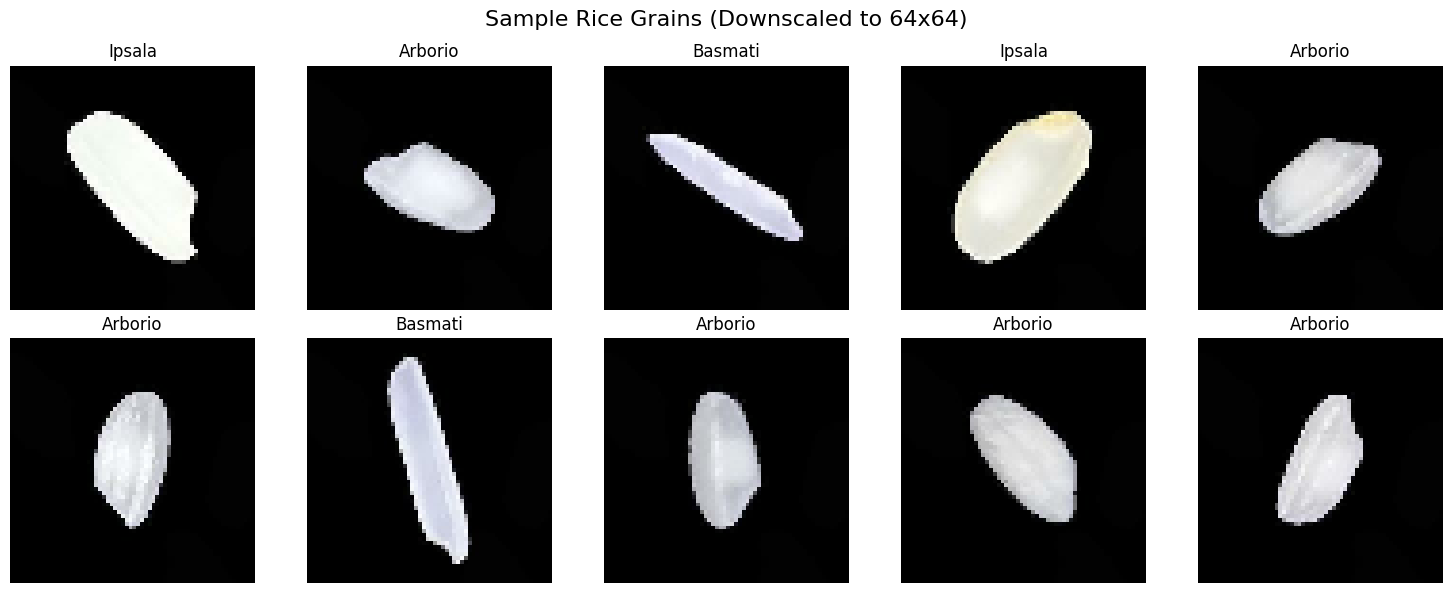

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pathlib
import os
import time

tf.keras.utils.set_random_seed(42)

base_extract_dir = pathlib.Path('rice_dataset')
target_dirs = list(base_extract_dir.rglob('Arborio'))
data_dir = target_dirs[0].parent if target_dirs else base_extract_dir

IMG_SIZE = (64, 64)
BATCH_SIZE = 32

print(f"Loading data from: {data_dir}")

# Load 70% Train (Shuffled)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.30, subset="training", seed=42, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True)
class_names = train_dataset.class_names

# Load 30% Val/Test (shuffle=False to prevent Data Leakage between val and test splits)
val_test_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.30, subset="validation", seed=42, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)

val_batches = tf.data.experimental.cardinality(val_test_dataset) // 2
val_dataset = val_test_dataset.take(val_batches)
test_dataset = val_test_dataset.skip(val_batches)

print(f"Classes: {class_names}")

# Optimize performance
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(AUTOTUNE)

# Visualize Samples
plt.figure(figsize=(15, 6))
for images, labels in train_dataset.take(1):
    for i in range(10):
        if i < len(images):
            ax = plt.subplot(2, 5, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(class_names[labels[i]])
            plt.axis("off")
plt.suptitle("Sample Rice Grains (Downscaled to 64x64)", fontsize=16)
plt.tight_layout()
plt.show()



## 2. Custom Architecture Design & Parameter Calculation

### Theoretical Justification for Activation Functions
As discussed in our Neural Networks lectures, using standard `Sigmoid` or `tanh` activation functions often leads to the **Vanishing Gradient problem**. During backpropagation, gradients become extremely small (close to zero at the tails), effectively halting weight updates in early layers.

To overcome this, both Model A and Model B utilize **ReLU (Rectified Linear Unit)** activation functions. ReLU solves the vanishing gradient issue because it does not saturate for positive values (its derivative is exactly 1). Furthermore, ReLU is computationally highly efficient—requiring only a simple thresholding operation `max(0, x)` rather than expensive exponential calculations. This is a critical advantage for our targeted edge device deployment.

### 2.1 Model A: Standard CNN
Model A interleaves standard `Conv2D` and `MaxPooling2D` layers.
* **Standard Conv2D Parameter Formula:** `Params = (K_h * K_w * C_in + 1) * C_out`
  * *Example calculation for the 1st Convolutional Layer (32 filters, 3x3 kernel, 3 input channels):*
    `(3 * 3 * 3 + 1) * 32 = 896 parameters`



In [6]:
from tensorflow.keras import layers, models

def build_model_a(input_shape=(64, 64, 3), num_classes=5):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Rescaling(1./255), # Normalize to [0, 1] natively
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name="Model_A_Standard_CNN")
    return model

model_a = build_model_a(num_classes=len(class_names))
print("="*50)
model_a.summary()



Model: "Model_A_Standard_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,597 (4.36 MB)

 Trainable params: 1,142,597 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

### 2.2 Model B: Lightweight CNN (Edge-Optimized)
Model B is specifically optimized to have fewer than 100k parameters. It achieves this by replacing standard convolutions with **Depthwise Separable Convolutions** (`SeparableConv2D`), which splits the spatial filtering and feature generation into two distinct steps: a spatial Depthwise step and a channel-mixing Pointwise (1x1) step.

* **Depthwise Separable Conv Parameter Formula:** `Params = (K_h * K_w * C_in) + (1 * 1 * C_in * C_out + C_out)`
  * *Example calculation for the 1st Separable Layer (32 filters, 3x3 kernel, 3 input channels):*
    * Depthwise portion: `(3 * 3 * 3) = 27`
    * Pointwise portion: `(1 * 1 * 3 * 32) + 32 = 128`
    * **Total:** `27 + 128 = 155 parameters`
  * This is a massive reduction compared to the 896 parameters required by the standard Conv2D layer in Model A!



In [8]:
def build_model_b(input_shape=(64, 64, 3), num_classes=5):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Rescaling(1./255), # Normalize to [0, 1] natively
        layers.SeparableConv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.SeparableConv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.SeparableConv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.SeparableConv2D(256, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name="Model_B_Lightweight_CNN")
    return model

model_b = build_model_b(num_classes=len(class_names))
print("="*50)
model_b.summary()



Model: "Model_B_Lightweight_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 64, 64, 32)     │           155 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 32, 32, 64)     │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 16, 16, 128)    │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_3              │ (None, 8, 8, 256)      │        34,176 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,168 (309.25 KB)

 Trainable params: 79,168 (309.25 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Optimizer Selection & Tuning
As established in our Deep Learning modules, optimization algorithms dictate how weights are updated during backpropagation. We evaluate 5 different optimizers:

1. **SGD (Stochastic Gradient Descent):** Updates parameters using the gradient of a single batch. Can easily get stuck in local minima or saddle points, causing slow convergence.
2. **SGD + Momentum:** Adds a velocity term to dampen oscillations and accelerate convergence past shallow local minima.
3. **RMSprop (Root Mean Square Propagation):** Addresses infinitesimally small learning rates by focusing on recent gradients and decaying older ones.
4. **Adagrad:** Adapts per-parameter learning rates, but can prematurely halt learning due to monotonic learning rate decay.
5. **Adam (Adaptive Moment Estimation):** Combines the benefits of both Momentum and RMSprop. It is highly robust, forgives poor hyperparameters, and typically achieves faster initial reductions in training error.


In [ ]:
EPOCHS_TUNE = 15 
learning_rate = 0.001

optimizers = {
    'SGD': tf.keras.optimizers.SGD(learning_rate=learning_rate),
    'SGD_Momentum': tf.keras.optimizers.SGD(learning_rate=learning_rate, momentum=0.9),
    'Adam': tf.keras.optimizers.Adam(learning_rate=learning_rate),
    'RMSprop': tf.keras.optimizers.RMSprop(learning_rate=learning_rate),
    'Adagrad': tf.keras.optimizers.Adagrad(learning_rate=learning_rate)
}
history_dict = {}

print("Comparing 5 Optimizers on Model B...")
for opt_name, opt in optimizers.items():
    print(f"\n--- Training with {opt_name} ---")
    temp_model = tf.keras.models.clone_model(model_b)
    temp_model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = temp_model.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS_TUNE, verbose=0) 
    history_dict[opt_name] = history.history
    print(f"{opt_name} Final Val Accuracy: {history.history['val_accuracy'][-1]:.4f}")

# Plot Convergence
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
for opt_name in optimizers.keys():
    plt.plot(history_dict[opt_name]['val_loss'], label=opt_name, marker='o')
plt.title('Validation Loss Comparison (5 Optimizers)')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True, alpha=0.6)

plt.subplot(1, 2, 2)
for opt_name in optimizers.keys():
    plt.plot(history_dict[opt_name]['val_accuracy'], label=opt_name, marker='^')
plt.title('Validation Accuracy Comparison (5 Optimizers)')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()



## 4. Custom Model Training & Evaluation 
We now train both Model A and Model B for **20 epochs** using the highest performing optimizer (Adam).

In [ ]:
EPOCHS = 20 # Rubric Requirement
model_a.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_b.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("TRAINING MODEL A (STANDARD CNN)...")
t0 = time.time()
hist_a = model_a.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS, verbose=1)
time_a = (time.time() - t0)/EPOCHS

print("\nTRAINING MODEL B (LIGHTWEIGHT CNN)...")
t0 = time.time()
hist_b = model_b.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS, verbose=1)
time_b = (time.time() - t0)/EPOCHS

model_a.save('model_a.h5'); model_b.save('model_b.h5')
size_a = os.path.getsize('model_a.h5') / 1024
size_b = os.path.getsize('model_b.h5') / 1024

print(f"\nModel A Size: {size_a:.2f} KB | Avg Time/Ep: {time_a:.2f}s")
print(f"Model B Size: {size_b:.2f} KB | Avg Time/Ep: {time_b:.2f}s")

# Plot Loss Curves
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_a.history['loss'], label='Train Loss A', marker='o')
plt.plot(hist_a.history['val_loss'], label='Val Loss A', marker='o')
plt.title('Model A: Loss Curves'); plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(hist_b.history['loss'], label='Train Loss B', marker='o')
plt.plot(hist_b.history['val_loss'], label='Val Loss B', marker='o')
plt.title('Model B: Loss Curves'); plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.show()

